In [4]:
from statsmodels.tsa.stattools import adfuller
import pandas as pd
import yfinance as yf

# 1. Get the data into a DataFrame named 'df'
msft_data = yf.Ticker('MSFT')
df = msft_data.history(start='2020-01-01')

# Clean columns if needed (removes multi-index if present)
df.columns = df.columns.get_level_values(0) if isinstance(df.columns, pd.MultiIndex) else df.columns

# Clean and view
df = df.dropna()
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Open,1644.0,3.224576e+02,1.003623e+02,1.298654e+02,2.380773e+02,3.122166e+02,4.091445e+02,5.508301e+02
High,1644.0,3.255953e+02,1.007757e+02,1.332398e+02,2.411433e+02,3.151245e+02,4.116389e+02,5.510484e+02
Low,1644.0,3.191622e+02,9.970448e+01,1.256096e+02,2.363711e+02,3.087726e+02,4.046752e+02,5.373668e+02
Close,1644.0,3.225056e+02,1.002486e+02,1.283583e+02,2.392247e+02,3.127219e+02,4.084648e+02,5.386586e+02
Volume,1644.0,2.838427e+07,1.326751e+07,5.855900e+06,2.006522e+07,2.522970e+07,3.286818e+07,1.862016e+08
Dividends,1644.0,1.096107e-02,8.796849e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,9.100000e-01
Stock Splits,1644.0,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


In [5]:
df['MA_50'] = df['Close'].rolling(window=50).mean()
df['MA_200'] = df['Close'].rolling(window=200).mean()

# 3. Create Daily Returns column for the second test
df['Daily_Return'] = df['Close'].pct_change()

In [6]:
def check_stationarity(series):
    # Perform Augmented Dickey-Fuller test
    result = adfuller(series.dropna(), autolag='AIC')
    
    print("--- ADF Test Results ---")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4f}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
        
    if result[1] <= 0.05:
        print("\nConclusion: Reject the null hypothesis. The series is STATIONARY.")
    else:
        print("\nConclusion: Fail to reject the null hypothesis. The series is NON-STATIONARY.")

# 4. FIX: Pass the 'df' columns into the stationarity check
print("Testing Raw Close Price:")
check_stationarity(df['Close'])

print("\nTesting Daily Returns:")
check_stationarity(df['Daily_Return'])

Testing Raw Close Price:
--- ADF Test Results ---
ADF Statistic: -1.6236
p-value: 0.4708
Critical Values:
   1%: -3.4343
   5%: -2.8633
   10%: -2.5677

Conclusion: Fail to reject the null hypothesis. The series is NON-STATIONARY.

Testing Daily Returns:
--- ADF Test Results ---
ADF Statistic: -12.9968
p-value: 0.0000
Critical Values:
   1%: -3.4344
   5%: -2.8633
   10%: -2.5677

Conclusion: Reject the null hypothesis. The series is STATIONARY.


[*********************100%***********************]  1 of 1 completed


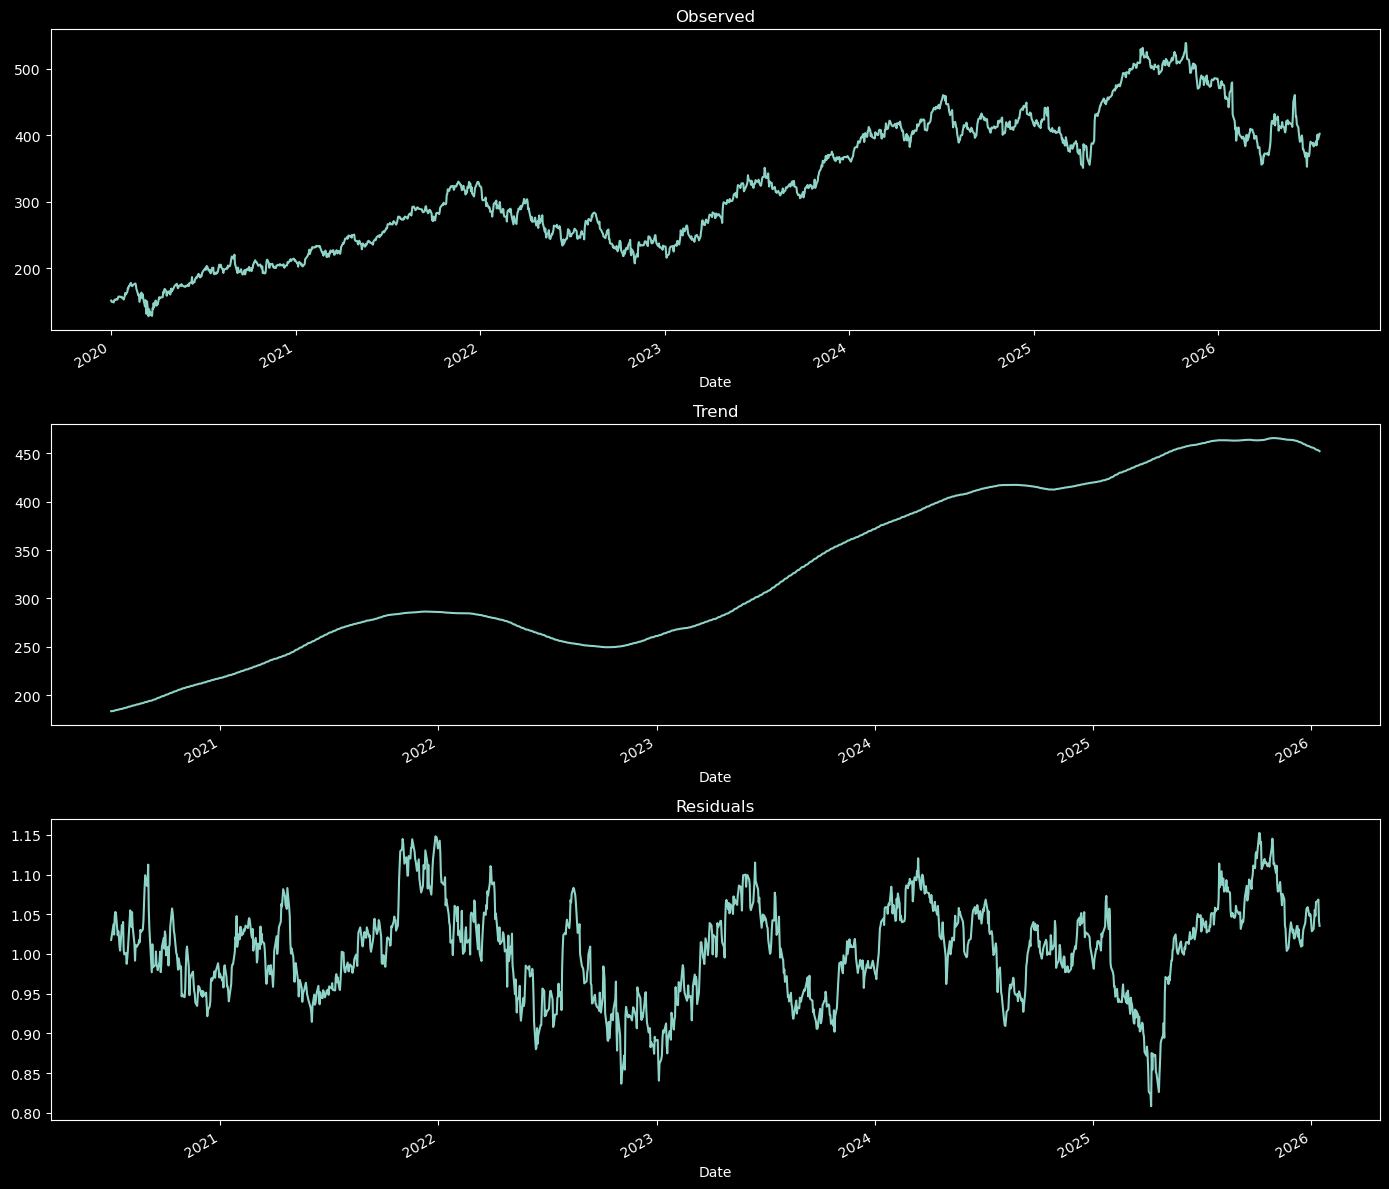

Results of Dickey-Fuller Test:
Test Statistic                   -1.623628
p-value                           0.470828
#Lags Used                        0.000000
Number of Observations Used    1643.000000
Critical Value (1%)              -3.434336
Critical Value (5%)              -2.863301
Critical Value (10%)             -2.567707
dtype: float64


In [7]:
import matplotlib.pyplot as plt
import pandas as pd
import yfinance as yf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

# --- Fix Data Fetching ---
msft_data = yf.download("MSFT", start="2020-01-01")

# --- 1. Moving Averages & Decomposition ---
msft_data["MA_50"] = msft_data["Close"].rolling(window=50).mean()
msft_data["MA_200"] = msft_data["Close"].rolling(window=200).mean()

# Perform decomposition on the DataFrame column
decomposition = seasonal_decompose(
    msft_data["Close"].dropna(), model="multiplicative", period=252
)

# Plot components
plt.style.use('dark_background')
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))
decomposition.observed.plot(ax=ax1, title="Observed")
decomposition.trend.plot(ax=ax2, title="Trend")
decomposition.resid.plot(ax=ax3, title="Residuals")
plt.tight_layout()
plt.show()


# --- 2. Stationarity Check ---
def check_stationarity(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)


# Run the test on the DataFrame column
check_stationarity(msft_data["Close"].dropna())


In [10]:
from statsmodels.tsa.arima.model import ARIMA
import numpy as np

df["Daily_Return"] = df["Close"].pct_change()
returns_series = df["Daily_Return"].dropna()
n_obs = len(returns_series)
acf_confidence_bound = 1.96 / np.sqrt(n_obs)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
    
print(f"Number of observations: {n_obs}")
print(f"95% ACF Significance Threshold: ±{acf_confidence_bound:.4f}")

# For MSFT daily returns, lags typically decay quickly. 
# We select an MA(2) model based on historical asset return behaviors.
ma_order_q = 2  

ma_model = ARIMA(returns_series, order=(0, 0, ma_order_q))
model_results = ma_model.fit()

print("\n" + "="*40)
print("          MA MODEL SUMMARY             ")
print("="*40)
print(model_results.summary().tables[1]) # Print the coefficient table

Number of observations: 1643
95% ACF Significance Threshold: ±0.0484


c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



          MA MODEL SUMMARY             
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      1.867      0.062   -3.83e-05       0.002
ma.L1         -0.1367      0.015     -8.909      0.000      -0.167      -0.107
ma.L2          0.0173      0.015      1.157      0.247      -0.012       0.047
sigma2         0.0003   7.18e-06     48.421      0.000       0.000       0.000


In [11]:
forecast_steps = 5  # Forecast the next 5 trading days
forecast_bundle = model_results.get_forecast(steps=forecast_steps)

forecast_means = forecast_bundle.predicted_mean
forecast_ci = forecast_bundle.conf_int(alpha=0.05)  # 95% Confidence Interval

# Format forecast into a readable tracking table
forecast_table = pd.DataFrame({
    'Expected Return': forecast_means,
    'Lower Bound (95%)': forecast_ci.iloc[:, 0],
    'Upper Bound (95%)': forecast_ci.iloc[:, 1]
})
print("\nNext 5-Day MSFT Returns Forecast:")
print(forecast_table.to_string())


Next 5-Day MSFT Returns Forecast:
      Expected Return  Lower Bound (95%)  Upper Bound (95%)
1643        -0.002004          -0.038556           0.034548
1644         0.001081          -0.035811           0.037972
1645         0.000767          -0.036130           0.037664
1646         0.000767          -0.036130           0.037664
1647         0.000767          -0.036130           0.037664


c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


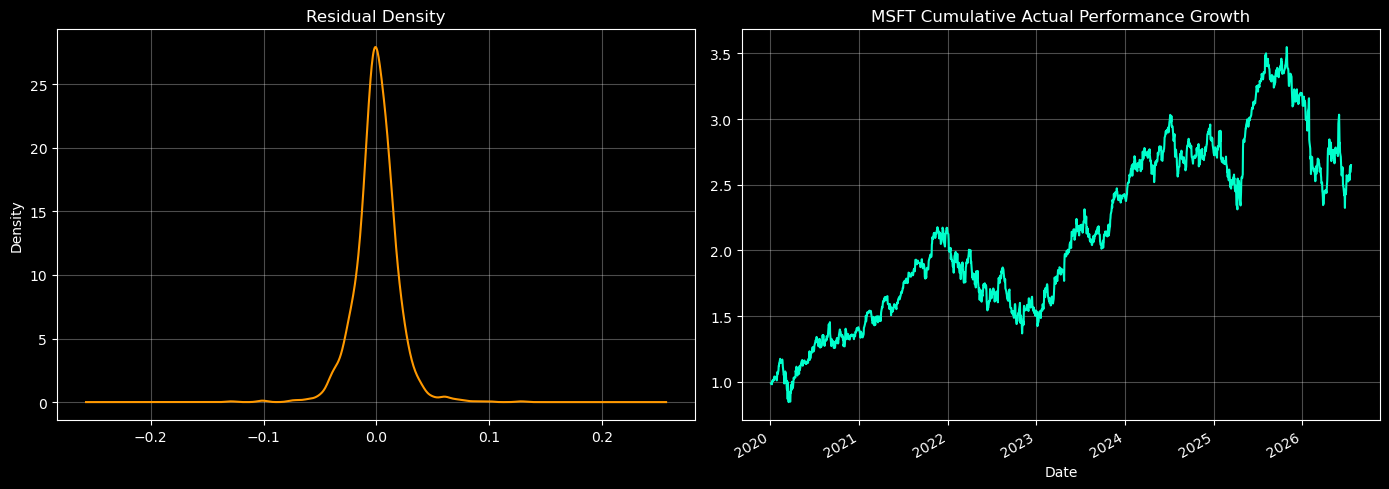

In [13]:
# A good MA model leaves behind "White Noise" residuals (no lingering ACF patterns)
residuals = model_results.resid

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
plt.style.use("dark_background")

# Visual 1: Residual Distribution
residuals.plot(kind='kde', ax=ax[0], color='#ff9900', title="Residual Density")
ax[0].grid(alpha=0.3)

# Visual 2: Cumulative returns tracking vs original
(returns_series + 1).cumprod().plot(ax=ax[1], color='#00ffcc', title="MSFT Cumulative Actual Performance Growth")
ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [14]:
test_size = 30
train = returns_series.iloc[:-test_size]
test = returns_series.iloc[-test_size:]

print(f"Training Observations: {len(train)}")
print(f"Testing Observations: {len(test)}")

p_order = 2
q_order = 2

arma_model = ARIMA(train, order=(p_order, 0, q_order))
model_results = arma_model.fit()

print("\n" + "="*50)
print("             ARMA(2,2) TRAINING SUMMARY           ")
print("="*50)
print(model_results.summary().tables[1])

Training Observations: 1613
Testing Observations: 30


c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)



             ARMA(2,2) TRAINING SUMMARY           
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0008      0.000      2.078      0.038    4.63e-05       0.002
ar.L1         -0.6071      0.127     -4.794      0.000      -0.855      -0.359
ar.L2          0.1537      0.140      1.100      0.271      -0.120       0.428
ma.L1          0.4854      0.130      3.745      0.000       0.231       0.739
ma.L2         -0.2844      0.146     -1.949      0.051      -0.570       0.002
sigma2         0.0003   7.79e-06     44.299      0.000       0.000       0.000


In [17]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

forecast_bundle = model_results.get_forecast(steps=test_size)
predictions = forecast_bundle.predicted_mean
conf_intervals = forecast_bundle.conf_int(alpha=0.05)

rmse = np.sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)

# Directional Accuracy: Did we correctly predict if the market goes up or down?
actual_direction = np.sign(test.values)
predicted_direction = np.sign(predictions.values)
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

c:\Users\Troy\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [18]:
rmse = np.sqrt(mean_squared_error(test, predictions))
mae = mean_absolute_error(test, predictions)

# Directional Accuracy: Did we correctly predict if the market goes up or down?
actual_direction = np.sign(test.values)
predicted_direction = np.sign(predictions.values)
directional_accuracy = np.mean(actual_direction == predicted_direction) * 100

print("\n" + "="*50)
print("             MODEL EVALUATION METRICS             ")
print("="*50)
print(f"Root Mean Squared Error (RMSE): {rmse:.5f}")
print(f"Mean Absolute Error (MAE):     {mae:.5f}")
print(f"Directional Accuracy:          {directional_accuracy:.2f}%")


             MODEL EVALUATION METRICS             
Root Mean Squared Error (RMSE): 0.02201
Mean Absolute Error (MAE):     0.01840
Directional Accuracy:          50.00%


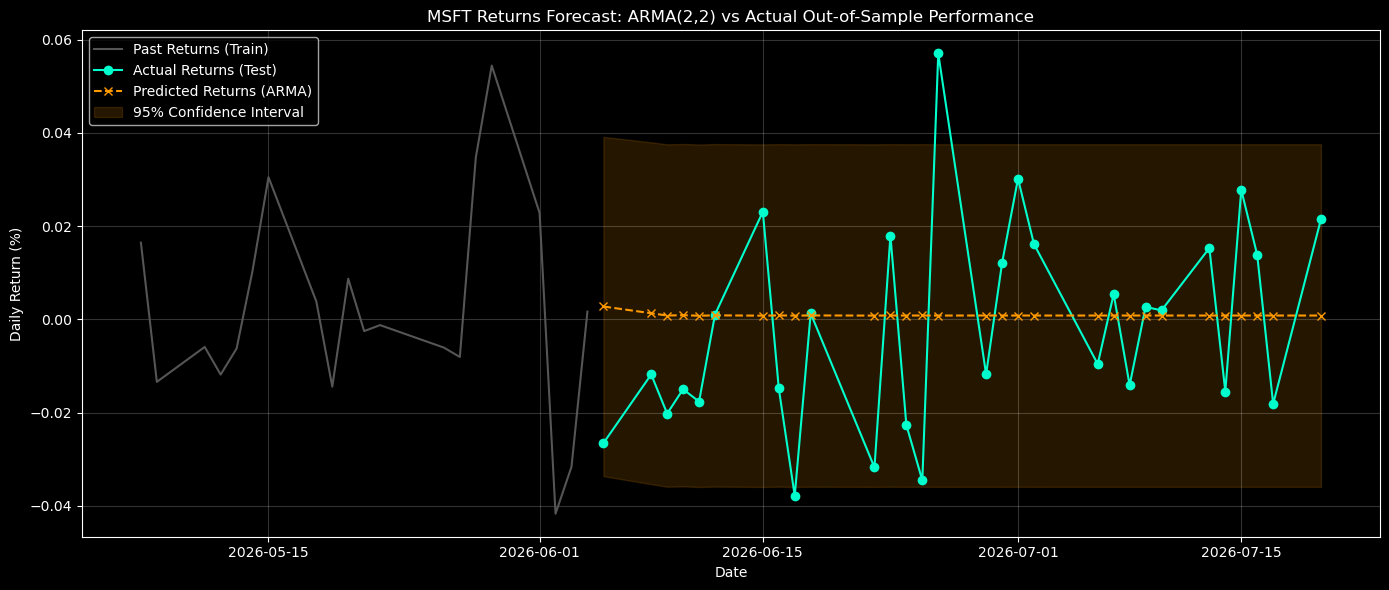

In [20]:
plt.style.use("dark_background")
plt.figure(figsize=(14, 6))

# Plot historical train baseline (last 20 days for context)
plt.plot(train.index[-20:], train.iloc[-20:], color="#555555", label="Past Returns (Train)")

# Plot actual vs predicted
plt.plot(test.index, test, color="#00ffcc", marker='o', label="Actual Returns (Test)")
plt.plot(test.index, predictions, color="#ff9900", linestyle="--", marker='x', label="Predicted Returns (ARMA)")

# Plot confidence intervals
plt.fill_between(
    test.index, 
    conf_intervals.iloc[:, 0], 
    conf_intervals.iloc[:, 1], 
    color="#ff9900", alpha=0.15, label="95% Confidence Interval"
)

plt.title("MSFT Returns Forecast: ARMA(2,2) vs Actual Out-of-Sample Performance")
plt.xlabel("Date")
plt.ylabel("Daily Return (%)")
plt.legend(loc="upper left")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()